In [1]:
import sys
print(sys.executable)

/resnick/groups/sxs/vtommasi/env311/bin/python


### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Import GPR library
import SimulationSupport.gpr as gpr
from SimulationSupport.gpr.diagnostics import loo_crossval, plot_loo_crossval, plot_loo_residuals
from SimulationSupport.EccentricityControl.ZeroEccParamsFromPN import omegaAndAdot

plt.style.use("plots.mplstyle")

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

import sxs
print(f"SXS version: {sxs.__version__}")

Device: cpu
SXS version: 2025.0.27


### Read in your chosen training data
For this example, we use data from the q83dAligned simulation campaign in the SXS catalog, corresponding to SXS IDs: SXS:BBH:1419 – SXS:BBH:1509. These runs are non-precessing binaries with mass ratios 1 ≤ q ≤ 8 and spins aligned with the orbital angular momentum.

We load the sxs catalog and filter to only keep the runs we want to train on

In [3]:
df = sxs.load("dataframe")
df = df[(df.index >= 'SXS:BBH:1419') & (df.index <= 'SXS:BBH:1509')]

print(f"Total simulations: {len(df)}")
df.head(5)

Loading SXS simulations using latest tag 'v3.0.0', published at 2025-05-14T18:17:30Z.
Total simulations: 91


,deprecated,reference_mass_ratio,reference_chi_eff,reference_chi1_perp,reference_chi2_perp,reference_eccentricity,reference_eccentricity_bound,reference_time,reference_dimensionless_spin1_x,reference_dimensionless_spin1_y,...,initial_position2,number_of_orbits,number_of_orbits_from_start,number_of_orbits_from_reference_time,DOI_versions,keywords,date_link_earliest,date_run_earliest,date_run_latest,date_postprocessing
SXS ID,,,,,,,,,,,,,,,,,,,,,
SXS:BBH:1419,False,7.997013,-0.799840,1.994280e-06,1.064214e-06,0.000536,0.000536,1206.5,-1.829859e-06,4.755456e-07,...,"[-11.865584989436478, 0.0278223811293813, 6.54...",16.646018,16.646018,12.870273,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0, v3.0]",[],2017-04-03 20:51:50,2017-06-23 06:52:21,2017-11-23 18:01:23,2025-01-28 17:15:45.045642
SXS:BBH:1420,False,7.996591,-0.622382,8.181529e-07,7.183138e-07,0.000241,0.000241,1100.0,-2.639596e-07,2.534627e-07,...,"[-11.691524862832026, 0.0279035300942018, 2.70...",17.281135,17.281135,13.801105,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0, v3.0]",[],2017-03-31 00:21:56,2017-06-09 06:29:04,2017-10-15 19:06:49,2025-01-28 17:52:02.384148
SXS:BBH:1421,False,7.809083,-0.448263,1.468047e-06,1.064243e-07,0.000821,0.000821,798.5,7.033512e-07,1.097131e-06,...,"[-11.523620524996687, 0.0267340786553965, -5.0...",18.504210,18.504210,15.973983,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0, v3.0]",[],2017-04-03 20:51:50,2017-07-14 07:17:00,2017-11-25 14:59:49,2025-01-28 17:56:35.354106
SXS:BBH:1422,False,7.952937,-0.762148,8.604935e-07,1.151197e-07,0.000159,0.000159,1251.0,6.023313e-07,-7.544145e-08,...,"[-11.832006041240176, 0.0275421838379813, -1.1...",16.776896,16.776896,12.847602,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0, v3.0]",[],2017-04-03 20:51:50,2017-04-27 14:26:28,2017-06-14 18:53:34,2025-01-28 17:52:33.309173
SXS:BBH:1423,False,7.996735,-0.620261,9.824482e-07,5.072383e-07,0.000586,0.000586,1193.0,-1.595184e-07,-1.092014e-06,...,"[-11.673766302509936, 0.0262858865567793, -4.1...",17.909408,17.909408,14.108192,"[, v1.1, v1.2, v1.3, v1.4, v1.5, v2.0, v3.0]",[],2017-04-25 02:07:24,2017-06-16 05:13:16,2017-10-23 03:38:53,2025-01-28 17:53:37.033045


For this example, we have 90 training points. We want to train the GPR to learn the values of the initial orbital frequency, Ω_0, and radial velocity, ˙a_0, that yield a BBH evolution with near-zero eccentricity. So we filter to keep only simulations with "zero" ending eccentricity. This number can be changed to fit your definition of 0 eccentricity. We utilize 1e-3 as our cutoff, and are left with 89 training points.

In [4]:
ecc_threshold = 1e-3
df = df[df["reference_eccentricity"] <= ecc_threshold]

df = df[[
    'initial_separation',
    'initial_orbital_frequency',
    'initial_adot',
    'initial_mass_ratio',
    'initial_dimensionless_spin1_x', 'initial_dimensionless_spin1_y', 'initial_dimensionless_spin1_z',
    'initial_dimensionless_spin2_x', 'initial_dimensionless_spin2_y', 'initial_dimensionless_spin2_z',
    'reference_eccentricity',
]]
print(f"Total simulations: {len(df)}")
df.head(5)

Total simulations: 90


,initial_separation,initial_orbital_frequency,initial_adot,initial_mass_ratio,initial_dimensionless_spin1_x,initial_dimensionless_spin1_y,initial_dimensionless_spin1_z,initial_dimensionless_spin2_x,initial_dimensionless_spin2_y,initial_dimensionless_spin2_z,reference_eccentricity
SXS ID,,,,,,,,,,,
SXS:BBH:1419,13.378235,0.018250,-0.000379,8.000000,3.610000e-14,-4.500000e-15,-0.800000,-1.121800e-12,-3.820000e-14,-0.800000,0.000536
SXS:BBH:1420,13.187256,0.018372,0.000463,8.000000,6.840000e-14,-3.440000e-14,-0.800000,8.601000e-13,-2.375000e-13,0.800000,0.000241
SXS:BBH:1421,13.027527,0.018658,0.000492,7.811462,-4.020000e-14,-7.500000e-15,-0.608090,1.972000e-13,-2.946000e-13,0.800000,0.000821
SXS:BBH:1422,13.349915,0.018733,-0.000139,7.954555,1.073700e-12,2.263000e-13,-0.800000,-3.911600e-12,-1.355800e-12,-0.459032,0.000159
SXS:BBH:1423,13.156250,0.018749,-0.000303,8.000000,-1.980000e-14,2.250000e-14,-0.603515,4.771000e-13,1.125000e-13,-0.753207,0.000586


### Post-Newtonian predictions
We also calculate the corresponding Post-Newtonian predictions over the same parameter space. This is done with OmegaAndAdot, the current function utilized in SpEC.

In [5]:
rPrime0 = 1

df["pn_guess_omega"] = np.nan
df["pn_guess_adot"]  = np.nan

for idx, row in df.iterrows():
    q = row["initial_mass_ratio"]
    r = row["initial_separation"]
    S1x, S1y, S1z = row["initial_dimensionless_spin1_x"], row["initial_dimensionless_spin1_y"], row["initial_dimensionless_spin1_z"]
    S2x, S2y, S2z = row["initial_dimensionless_spin2_x"], row["initial_dimensionless_spin2_y"], row["initial_dimensionless_spin2_z"]

    omega, adot = omegaAndAdot(r, q, np.array([S1x, S1y, S1z]), np.array([S2x, S2y, S2z]), rPrime0)

    df.at[idx, "pn_guess_omega"] = omega
    df.at[idx, "pn_guess_adot"] = adot

print(f"Total simulations: {len(df)}")
df.head(5)

Total simulations: 90


,initial_separation,initial_orbital_frequency,initial_adot,initial_mass_ratio,initial_dimensionless_spin1_x,initial_dimensionless_spin1_y,initial_dimensionless_spin1_z,initial_dimensionless_spin2_x,initial_dimensionless_spin2_y,initial_dimensionless_spin2_z,reference_eccentricity,pn_guess_omega,pn_guess_adot
SXS ID,,,,,,,,,,,,,
SXS:BBH:1419,13.378235,0.018250,-0.000379,8.000000,3.610000e-14,-4.500000e-15,-0.800000,-1.121800e-12,-3.820000e-14,-0.800000,0.000536,0.018793,-0.000041
SXS:BBH:1420,13.187256,0.018372,0.000463,8.000000,6.840000e-14,-3.440000e-14,-0.800000,8.601000e-13,-2.375000e-13,0.800000,0.000241,0.019066,-0.000042
SXS:BBH:1421,13.027527,0.018658,0.000492,7.811462,-4.020000e-14,-7.500000e-15,-0.608090,1.972000e-13,-2.946000e-13,0.800000,0.000821,0.019335,-0.000043
SXS:BBH:1422,13.349915,0.018733,-0.000139,7.954555,1.073700e-12,2.263000e-13,-0.800000,-3.911600e-12,-1.355800e-12,-0.459032,0.000159,0.018827,-0.000041
SXS:BBH:1423,13.156250,0.018749,-0.000303,8.000000,-1.980000e-14,2.250000e-14,-0.603515,4.771000e-13,1.125000e-13,-0.753207,0.000586,0.019174,-0.000042


### GPR Training
We extract the training inputs for the GPR:
1. initial separation, D_0
2. mass ratio, q
3. and the spins of each black hole, S_1 and S_2 - for these aligned-spin cases, we only take S_z

In [6]:
# Extract training inputs - same for omega and adot
features = [
    "initial_separation",
    "initial_mass_ratio",
    "initial_dimensionless_spin1_z",
    "initial_dimensionless_spin2_z"
]

# Turn columns into numpy array
X = df[features].values

We take the PN guesses as our baseline, and train two independent GPR models on the residuals between the final simulation values and this baseline.

/resnick/groups/sxs/vtommasi/env311/lib/python3.11/site-packages/gpytorch/models/exact_gp.py:299: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


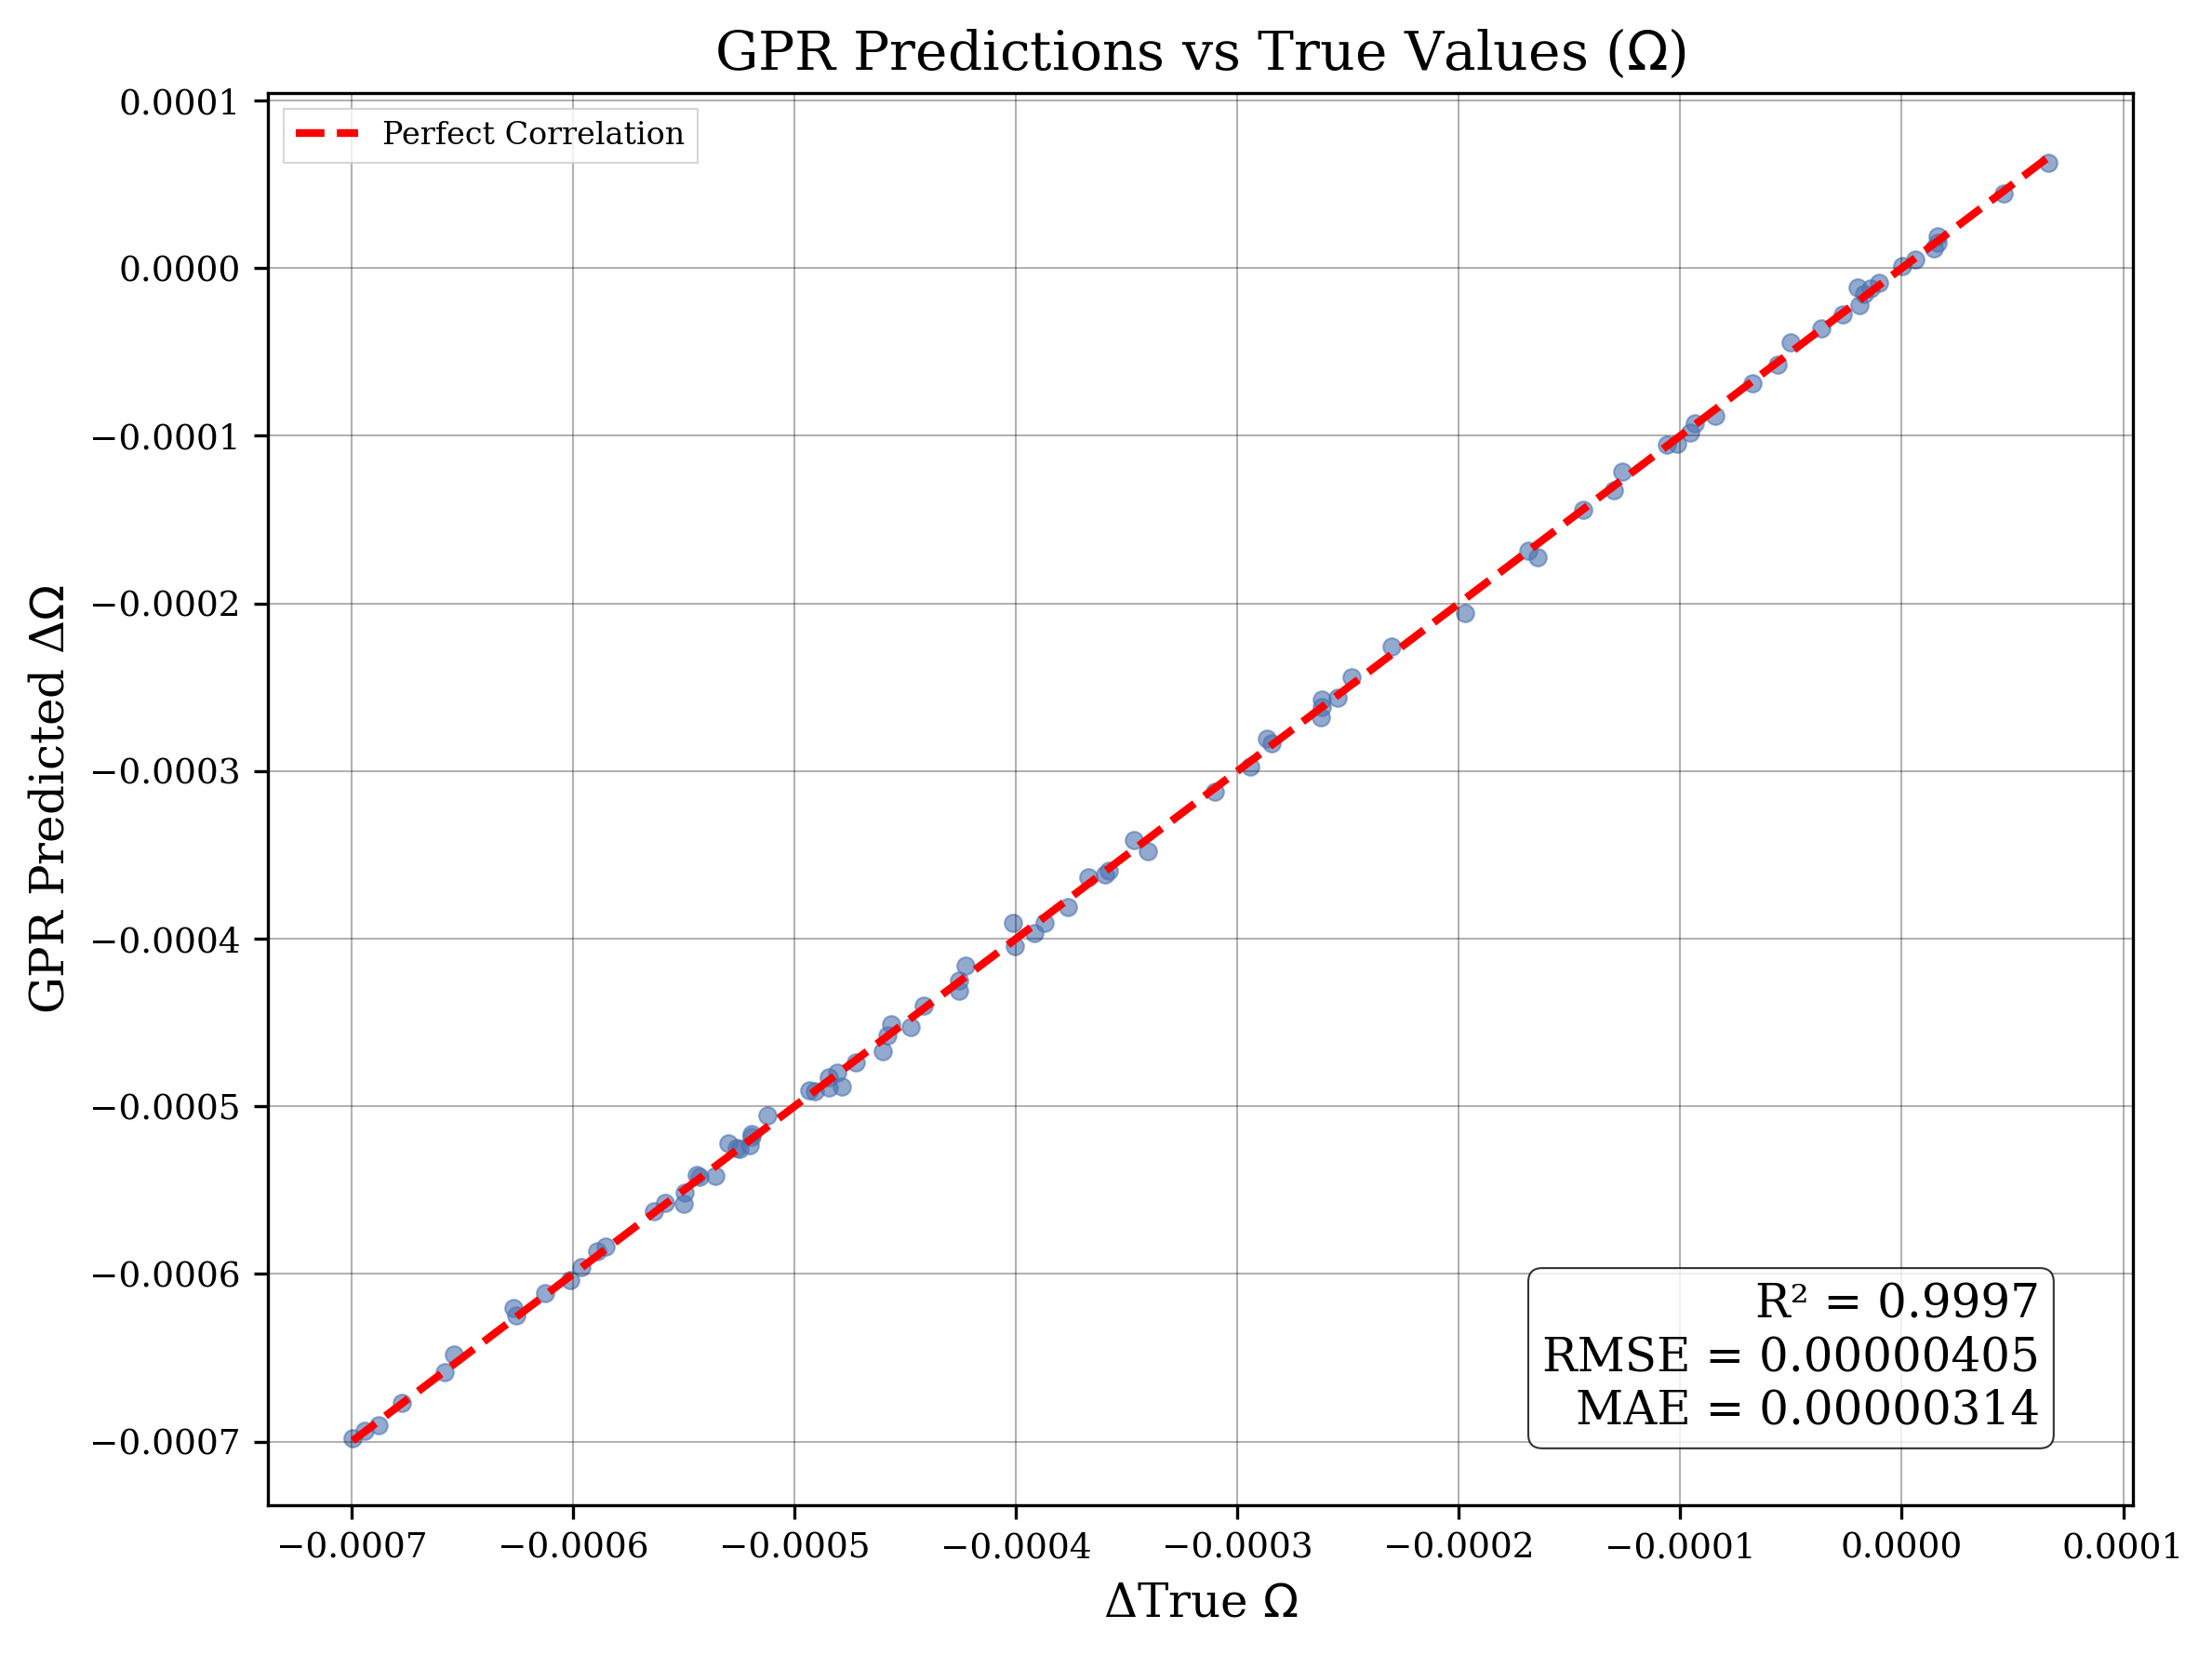

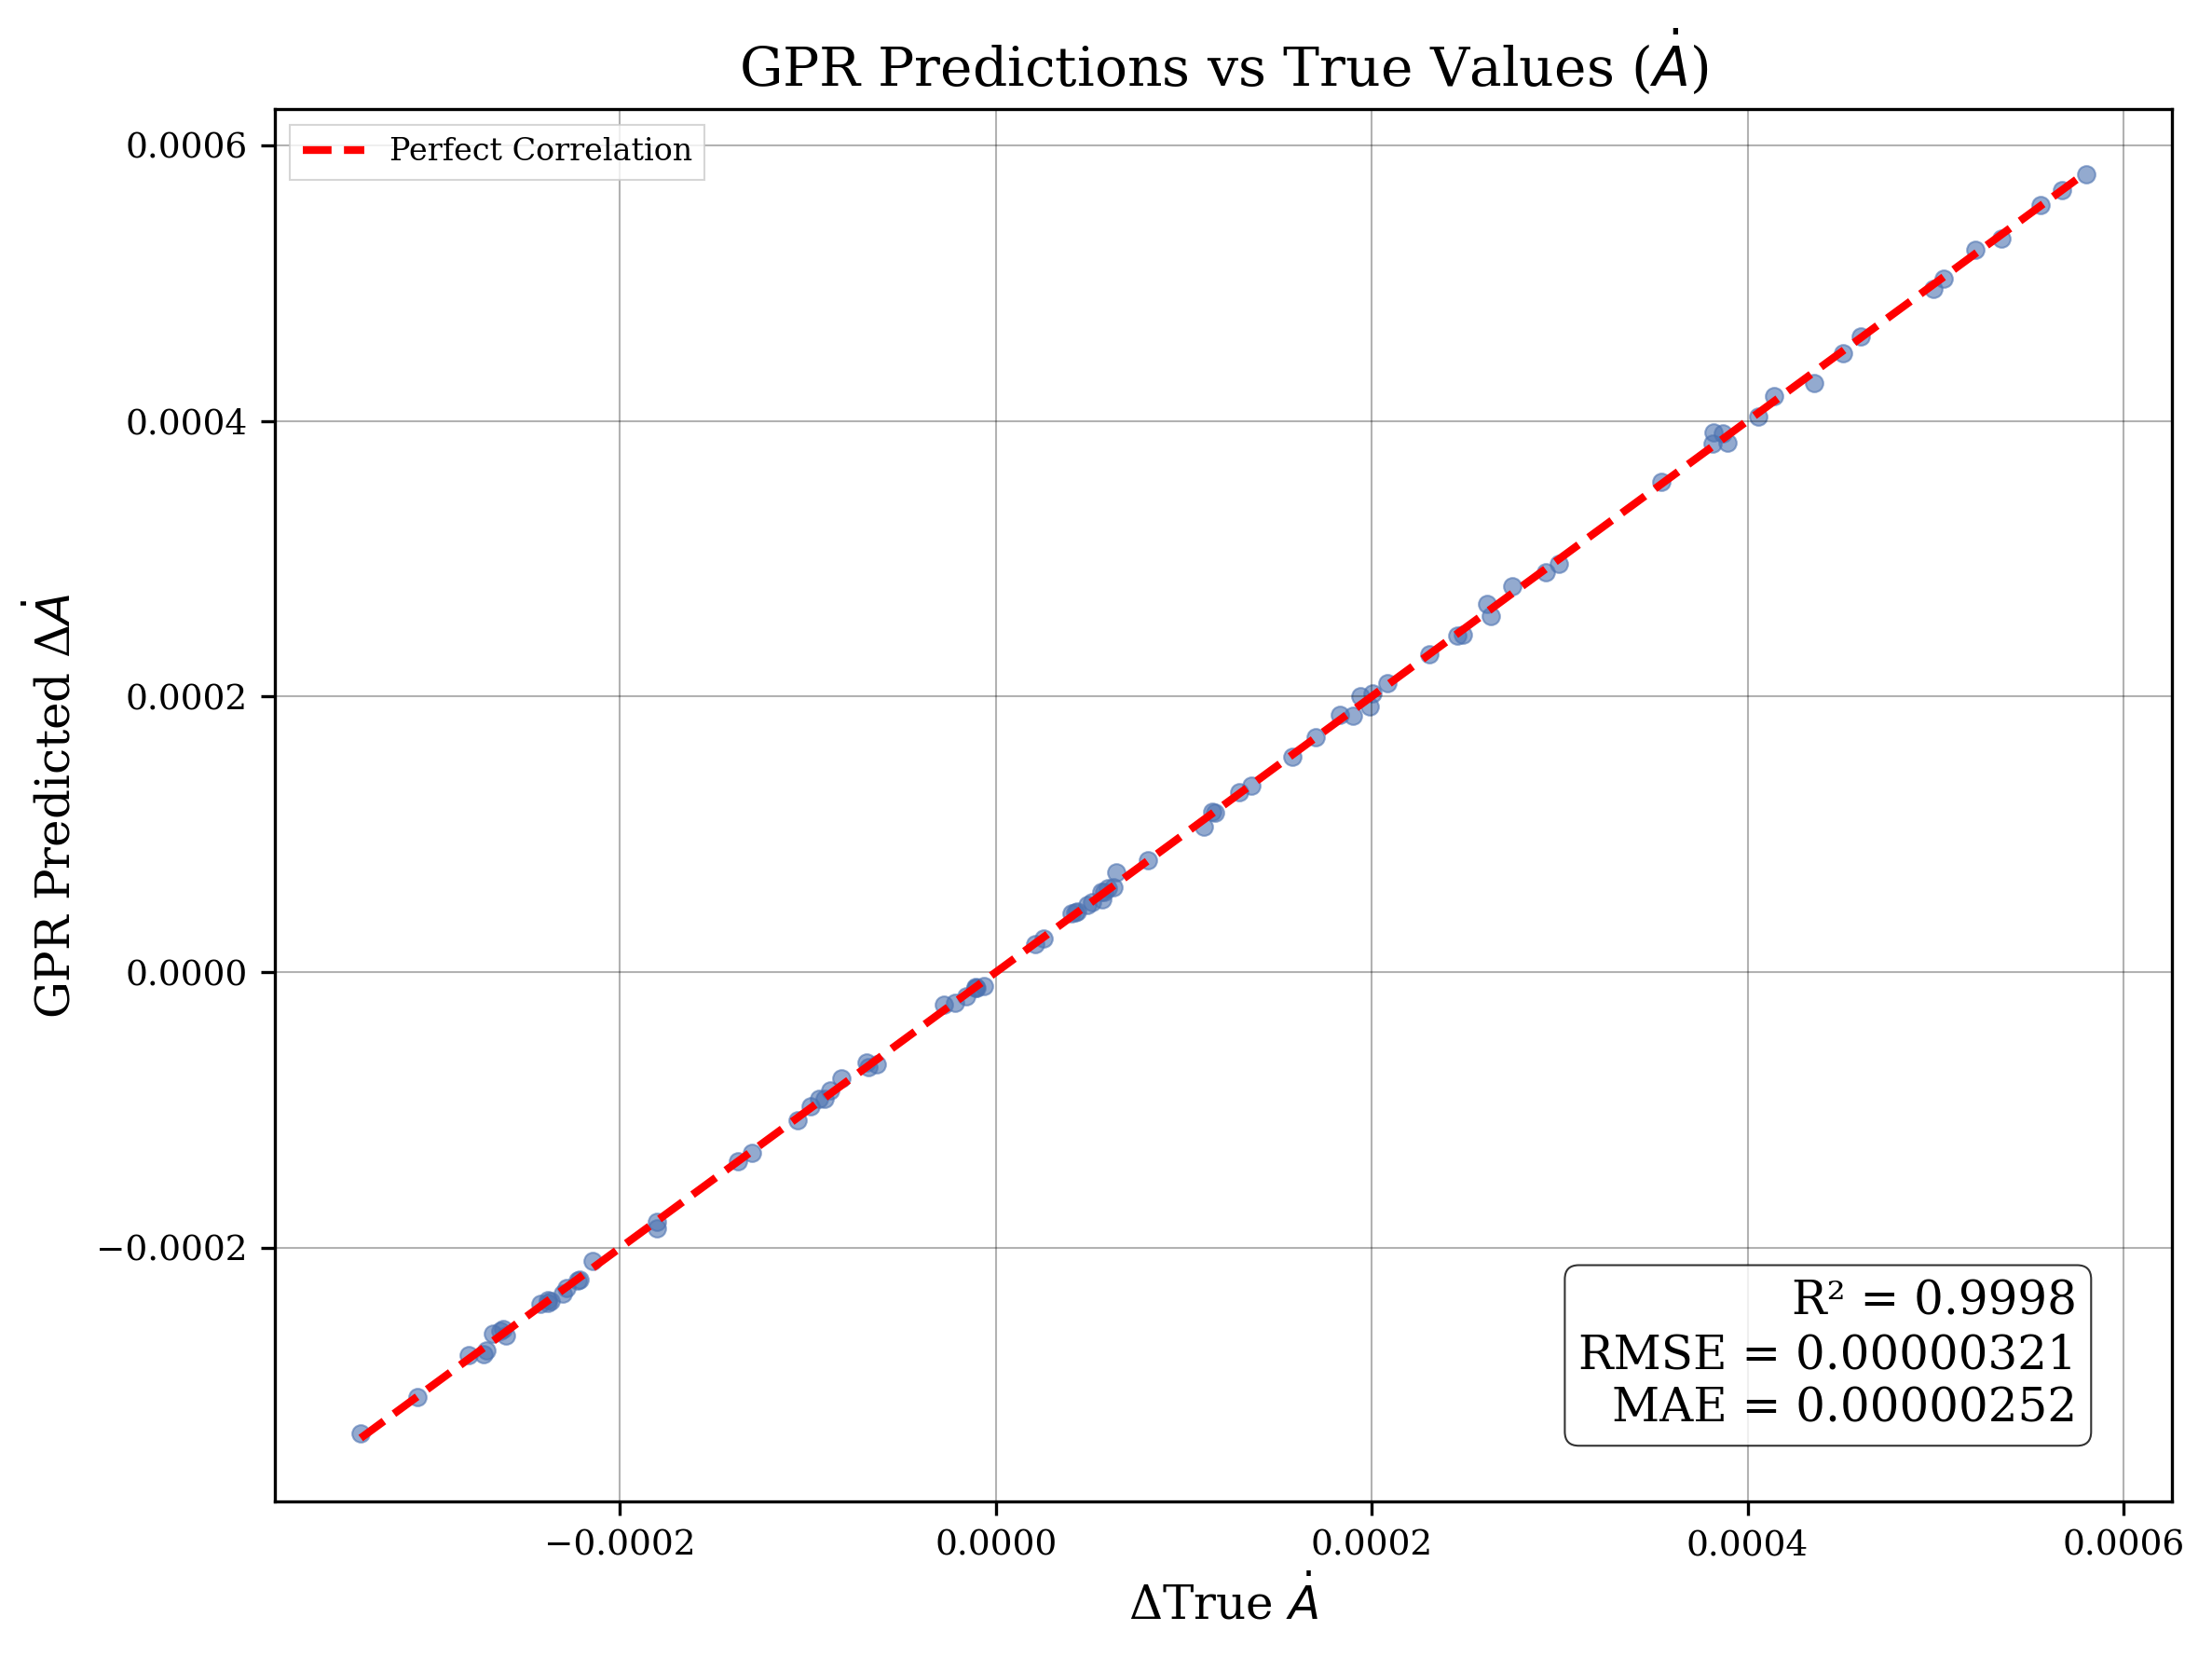

In [7]:
# Omega
# Prepare target features Y
baseline_omega = "pn_guess_omega"
training_omega = "initial_orbital_frequency"

# Prepare target difference,
# ie the difference between the output values from the simulations to the PN guesses for
# the initial values
Y_omega = df[training_omega].values - df[baseline_omega].values
# Run full GPR pipeline
model_omega, likelihood_omega, Y_pred_omega = gpr.run_gpr_pipeline(X, Y_omega, target_name="$\Omega$")

# Adot
# Prepare target features Y
baseline_adot = "pn_guess_adot"
training_adot = "initial_adot"

# Prepare target difference
Y_adot = df[training_adot].values - df[baseline_adot].values
# Run full GPR pipeline
model_adot, likelihood_adot, Y_pred_adot = gpr.run_gpr_pipeline(X, Y_adot, target_name = "$\dot{A}$")

### Model Validation
To assess our model's performance, we utilize a leave-one-out cross-validation, in which each data point is withheld in turn from the training set and predicted by a GPR trained on the remaining data. We plot the results of this LOO and summary statistics to analyze how our model did. An unbiased model should yield LOO residuals centered around zero.

In [ ]:
# Prepare target feature Y
targets = [
    ("pn_guess_omega", "initial_orbital_frequency", "omega"),
    ("pn_guess_adot", "initial_adot", "adot")
]

for baseline_col, final_col, name in targets:
    # Fit to the difference between the output omega values from the simulations to the
    # PN guesses for the initial values
    Y = df[final_col].values - df[baseline_col].values

    preds_loo, stds_loo = loo_crossval(
        X,
        Y,
        target_name=name
    )

    # Plot correlation and compute statistics
    rmse_loo, mae_loo, r2_loo = plot_loo_crossval(
        Y,
        preds_loo,
        target_name=name,
        plot=True
    )

    # Plot residuals
    plot_loo_residuals(Y, preds_loo, target_name=name, show=False)

    ax = plt.gca()  # get current axes
    ax.xaxis.get_offset_text().set_fontsize(14)

    if name == "omega":
        ax.set_xlabel(r"$\Omega_0$ Residuals")
    elif name == "adot":
        ax.set_xlabel(r"$\dot{a}_0$ Residuals")

    plt.show()

### Saving the model
After training the model, we can save it to disk by storing the model parameters, likelihood, and metadata. This means you can evalute the GPR without having to retrain each time.

In [ ]:
# Save both checkpoints
gpr.save_gpr_checkpoint(
    model_omega,likelihood_omega, features,
    output_name="omega",
    run_col="initial_orbital_frequency",
    base_column="pn_guess_omega",
    X=X, Y=Y_omega,
    path="gpr_model_omega.pth"
)

gpr.save_gpr_checkpoint(
    model_adot, likelihood_adot, features,
    output_name="adot",
    run_col="initial_adot",
    base_column="pn_guess_adot",
    X=X, Y=Y_adot,
    path="gpr_model_adot.pth"
)

### Example of how to load the pre-trained model and evaluate
Once the model is saved to disk, you can load it and correct new runs. For this example, we utilize SXS:BBH:1419 (which is also included in training, and is simply used as an example).

In [ ]:
# Load models from disk
model_omega, likelihood_omega, meta_omega = gpr.load_gpr_checkpoint("gpr_model_omega.pth")
model_adot, likelihood_adot, meta_adot    = gpr.load_gpr_checkpoint("gpr_model_adot.pth")

# Define a single test point (must match the feature orders used during training)
sim_id = 'SXS:BBH:1419'
row = df.loc[sim_id]

test_point = {
    "initial_separation": row["initial_separation"],
    "initial_mass_ratio": row["initial_mass_ratio"],
    "initial_dimensionless_spin1_x": row["initial_dimensionless_spin1_x"],
    "initial_dimensionless_spin1_y": row["initial_dimensionless_spin1_y"],
    "initial_dimensionless_spin1_z": row["initial_dimensionless_spin1_z"],
    "initial_dimensionless_spin2_x": row["initial_dimensionless_spin2_x"],
    "initial_dimensionless_spin2_y": row["initial_dimensionless_spin2_y"],
    "initial_dimensionless_spin2_z": row["initial_dimensionless_spin2_z"],
}

# Convert to numpy array in the correct feature order
X_test = np.array([[test_point[f] for f in features]])

# Get PN baseline for this point
omega_pn, adot_pn = omegaAndAdot(
    test_point["initial_separation"],
    test_point["initial_mass_ratio"],
    np.array([test_point["initial_dimensionless_spin1_x"], test_point["initial_dimensionless_spin1_y"], test_point["initial_dimensionless_spin1_z"]]),
    np.array([test_point["initial_dimensionless_spin2_x"], test_point["initial_dimensionless_spin2_y"], test_point["initial_dimensionless_spin2_z"]]),
    rPrime0
)

# Make GPR prediction
delta_omega, sigma_omega = gpr.predict_with_gpr_model(X_test, model_omega, likelihood_omega)
delta_adot, sigma_adot   = gpr.predict_with_gpr_model(X_test, model_adot, likelihood_adot)

# Final corrected values = PN baseline + GPR correction
omega_gpr_corrected = omega_pn + delta_omega[0]
adot_gpr_corrected  = adot_pn + delta_adot[0]

# Past run simulation values for comparison
original_omega = float(row["initial_orbital_frequency"])
original_adot  = float(row["initial_adot"])

print(f"Results for {sim_id}:")
print(f"Original omega:       {original_omega:.15f}")
print(f"PN omega:             {omega_pn:.15f}")
print(f"GPR correction:       {delta_omega[0]:.15f} ± {sigma_omega[0]:.15f}")
print(f"GPR corrected omega:  {omega_gpr_corrected:.15f}")
print()
print(f"Original adot:        {original_adot:.15f}")
print(f"PN adot:              {adot_pn:.15f}")
print(f"GPR correction:       {delta_adot[0]:.15f} ± {sigma_adot[0]:.15f}")
print(f"GPR corrected adot:   {adot_gpr_corrected:.15f}")